           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
Region                                     28
Date                                       28
Frequency    

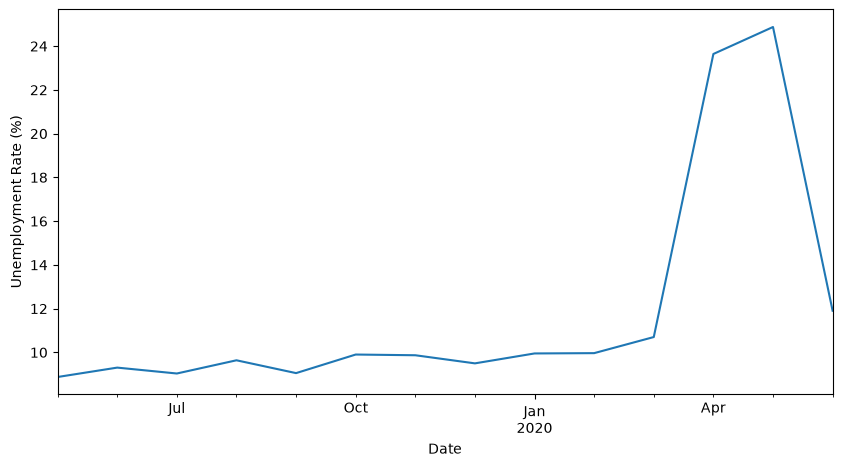

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


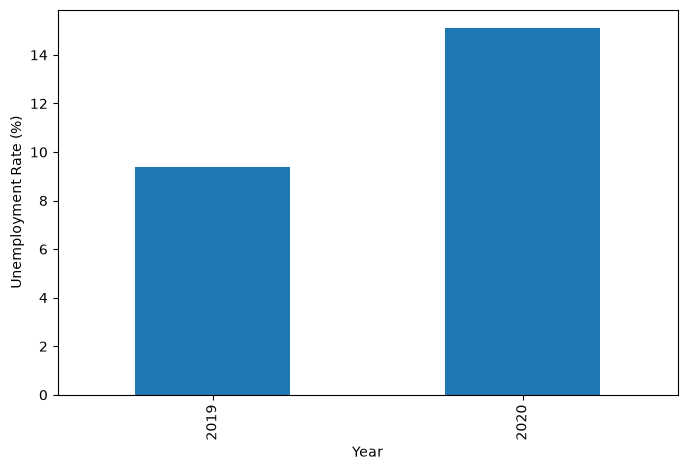

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Unemployment in India.csv")
df.columns = df.columns.str.strip()
print(df.head())

# Check and remove missing values
print(df.isnull().sum())
df = df.dropna()

# Convert date column and extract year/month
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

print(df.describe())

# Overall unemployment trend over time
plt.figure(figsize=(10,5))
df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot()
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

# Year-wise average unemployment rate
yearly_avg = df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()
print(yearly_avg)

yearly_avg.plot(kind='bar', figsize=(8,5))
plt.ylabel("Unemployment Rate (%)")
plt.show()

# Month-wise average to check seasonal pattern
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
print(monthly_avg)

# Region-wise comparison
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(region_avg.head(10))